# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import joblib
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load Preprocessed Data

In [2]:
# Sentiment
X_train_tfidf, X_test_tfidf, y_train_sent, y_test_sent = joblib.load('../models/sentiment_data.pkl')

# Rating
X_train_rating, X_test_rating, y_train_rating, y_test_rating = joblib.load('../models/rating_data.pkl')

# Sentiment Classification

In [3]:
# logistic regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train_sent)
y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Classification Report:")
print(classification_report(y_test_sent, y_pred_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.51      0.63       521
     neutral       0.65      0.15      0.25       583
    positive       0.95      1.00      0.97     12458

    accuracy                           0.94     13562
   macro avg       0.81      0.55      0.61     13562
weighted avg       0.93      0.94      0.93     13562



In [4]:
# random forest classifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_tfidf, y_train_sent)
y_pred_rf = rf_model.predict(X_test_tfidf)

print("Random Forest Classification Report:")
print(classification_report(y_test_sent, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.49      0.63       521
     neutral       0.98      0.38      0.55       583
    positive       0.95      1.00      0.98     12458

    accuracy                           0.95     13562
   macro avg       0.95      0.62      0.72     13562
weighted avg       0.95      0.95      0.94     13562



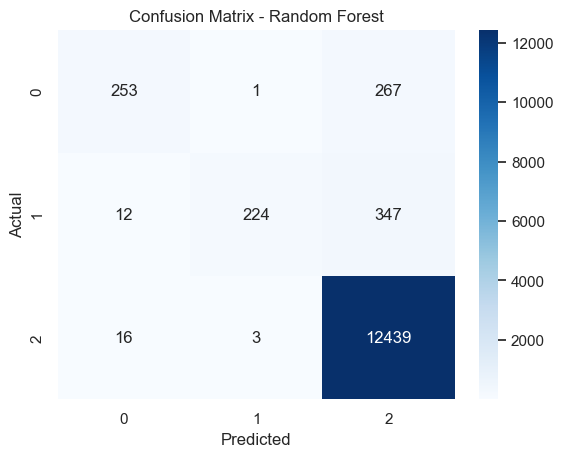

In [5]:
# confusion matrix
cm = confusion_matrix(y_test_sent, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Rating Prediction

In [7]:
# linear regression
lr_reg = LinearRegression()
lr_reg.fit(X_train_rating, y_train_rating)
y_pred_lr_reg = lr_reg.predict(X_test_rating)
import numpy as np
mse = mean_squared_error(y_test_rating, y_pred_lr_reg)
rmse = np.sqrt(mse)
print("Linear Regression RMSE:", rmse)
print("R2 Score:", r2_score(y_test_rating, y_pred_lr_reg))

Linear Regression RMSE: 0.8322292485340941
R2 Score: 0.013397190786441526


In [8]:
# random forest regressor
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train_rating, y_train_rating)
y_pred_rf_reg = rf_reg.predict(X_test_rating)

mse_rf = mean_squared_error(y_test_rating, y_pred_rf_reg)
rmse_rf = np.sqrt(mse_rf)
print("Random Forest RMSE:", rmse_rf)
print("R2 Score:", r2_score(y_test_rating, y_pred_rf_reg))

Random Forest RMSE: 0.8390620335075019
R2 Score: -0.0028697654929277228


# Save final versions

In [9]:
joblib.dump(rf_model, '../models/sentiment_rf_model.pkl')
joblib.dump(rf_reg, '../models/rating_rf_model.pkl')

['../models/rating_rf_model.pkl']